In [1]:
!pip install geopandas



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


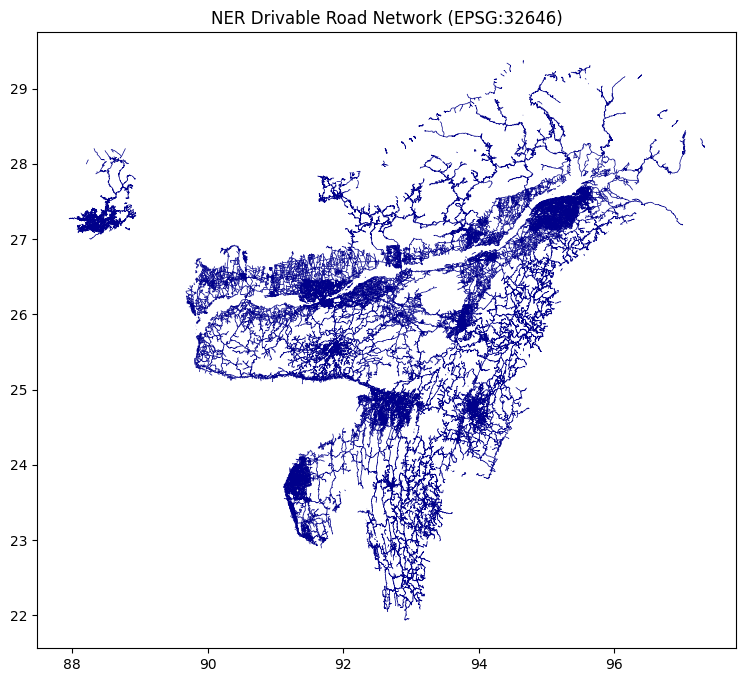

In [2]:
import geopandas as gpd
import matplotlib.pyplot as plt


roads_gdf = gpd.read_file("TransportWays/ner_roads.geojson")


fig, ax = plt.subplots(figsize=(12, 8))
roads_gdf.plot(ax=ax, linewidth=0.5, color='darkblue')
ax.set_title("NER Drivable Road Network (EPSG:32646)")
plt.show()

In [4]:
!pip install networkx


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


In [ ]:
#making a graph here 

In [9]:
#why are there two disconected graphs???????? 
#sky is not connceted to the ground butt i can connect roads to runways cant i 

In [27]:
import networkx as nx
import geopandas as gpd
import itertools
import numpy as np
from scipy.spatial import cKDTree
import math

def snap(coord):
    return (round(coord[0]), round(coord[1]))

def fast_distance(u, v):
    return math.hypot(v[0] - u[0], v[1] - u[1])

G = nx.Graph()

print("1. Parsing Road Geometries...")
roads_gdf = gpd.read_file("TransportWays/ner_roads.geojson").to_crs(epsg=32646)
road_edges = [] # Temporary list for bulk insertion
total_roads = len(roads_gdf)

for idx, row in roads_gdf.iterrows():
    if idx % 50000 == 0 and idx > 0:
        print(f"   -> Parsed {idx} / {total_roads} roads...")
        
    geom = row.geometry
    if not geom: continue
    
    lines = list(geom.geoms) if geom.geom_type == 'MultiLineString' else [geom]
    for line in lines:
        if line.geom_type == 'LineString':
            coords = list(line.coords)
            for i in range(len(coords) - 1):
                u, v = snap(coords[i]), snap(coords[i+1])
                if u != v: 
                    road_edges.append((u, v, {"mode": "road", "length_m": fast_distance(u, v), "capacity_tons": 50}))

print(f"   -> Bulk injecting {len(road_edges)} road segments into NetworkX...")
G.add_edges_from(road_edges)
del road_edges # Delete list to free up RAM immediately

print("2. Parsing Waterways...")
water_gdf = gpd.read_file("TransportWays/ner_waterways.geojson").to_crs(epsg=32646)
water_edges = []
for _, row in water_gdf.iterrows():
    geom = row.geometry
    if not geom: continue
    
    lines = list(geom.geoms) if geom.geom_type == 'MultiLineString' else [geom]
    for line in lines:
        if line.geom_type == 'LineString':
            coords = list(line.coords)
            for i in range(len(coords) - 1):
                u, v = snap(coords[i]), snap(coords[i+1])
                if u != v:
                    water_edges.append((u, v, {"mode": "water", "length_m": fast_distance(u, v), "capacity_tons": 5}))
G.add_edges_from(water_edges)

print("3. Parsing Aviation Nodes...")
air_gdf = gpd.read_file("TransportWays/ner_air_nodes.geojson").to_crs(epsg=32646)
air_nodes = [snap(list(geom.coords)[0]) for geom in air_gdf.geometry if geom]
air_edges = []
for u, v in itertools.combinations(air_nodes, 2):
    if u != v: 
        dist = fast_distance(u, v)
        if 0 < dist <= 150000: 
            air_edges.append((u, v, {"mode": "air", "length_m": dist, "capacity_tons": 2}))
G.add_edges_from(air_edges)

print("4. Building KDTree & Snapping Transshipment Hubs...")
road_nodes = [n for n in G.nodes() if any(G[n][nbr].get('mode') == 'road' for nbr in G.neighbors(n))]
road_nodes_2d = [(n[0], n[1]) for n in road_nodes]

if not road_nodes_2d:
    raise ValueError("CRITICAL ERROR: 0 road nodes ingested.")

tree = cKDTree(np.array(road_nodes_2d))
hub_edges = []

for air_node in air_nodes:
    dist, idx = tree.query((air_node[0], air_node[1]), k=1)
    hub_edges.append((air_node, road_nodes[idx], {"mode": "transshipment", "length_m": dist, "capacity_tons": 50}))

water_nodes = [n for n in G.nodes() if any(G[n][nbr].get('mode') == 'water' for nbr in G.neighbors(n))]
for w_node in water_nodes:
    dist, idx = tree.query((w_node[0], w_node[1]), k=1)
    if dist <= 5000:
        hub_edges.append((w_node, road_nodes[idx], {"mode": "transshipment_port", "length_m": dist, "capacity_tons": 5}))

G.add_edges_from(hub_edges)

print("5. Purging Isolated Artifacts (In-Place LCC)...")
components = sorted(nx.connected_components(G), key=len, reverse=True)
nodes_to_remove = set()
for component in components[1:]:
    nodes_to_remove.update(component)

print(f"   -> Deleting {len(nodes_to_remove)} orphaned nodes...")
G.remove_nodes_from(nodes_to_remove)

print(f"Final Integrated Graph: {G.number_of_nodes()} Nodes, {G.number_of_edges()} Edges")

1. Parsing Road Geometries...
   -> Parsed 50000 / 237189 roads...
   -> Parsed 100000 / 237189 roads...
   -> Parsed 150000 / 237189 roads...
   -> Parsed 200000 / 237189 roads...
   -> Bulk injecting 6308834 road segments into NetworkX...
2. Parsing Waterways...
3. Parsing Aviation Nodes...
4. Building KDTree & Snapping Transshipment Hubs...
5. Purging Isolated Artifacts (In-Place LCC)...
   -> Deleting 398208 orphaned nodes...
Final Integrated Graph: 6491315 Nodes, 7133277 Edges


In [28]:
print("Calculating baseline travel times for 7.1M edges...")

# Baseline speeds in km/h adapted for NER topography and transport constraints
SPEEDS_KMH = {
    "road": 35,              # Mountainous/hilly terrain average truck speed
    "water": 15,             # NDRF motorized relief boats navigating currents
    "air": 160,              # Heavy-lift drone / helicopter cruising speed
    "transshipment": 5,      # Virtual speed simulating airport cargo loading
    "transshipment_port": 2  # Extremely slow mud-bank offloading to boats
}

# Pre-allocate dictionaries for high-speed bulk attribute assignment
speeds_attr = {}
times_attr = {}

# Iterate once and calculate mathematics in memory
for u, v, data in G.edges(data=True):
    mode = data.get("mode", "road")
    length_m = data.get("length_m", 0.0)
    
    speed = SPEEDS_KMH.get(mode, 10)
    
    # Formula: Time (min) = (Distance in km / Speed in km/h) * 60
    time_min = (length_m / 1000.0) / speed * 60.0 if speed > 0 else float('inf')
        
    speeds_attr[(u, v)] = speed
    times_attr[(u, v)] = time_min

# Bulk assign the calculated values back into the NetworkX graph
nx.set_edge_attributes(G, speeds_attr, "speed_kmh")
nx.set_edge_attributes(G, times_attr, "travel_time_min")

print("Routing weights applied successfully.")

# Verify the mathematical output on the first recorded edge
sample_edge = list(G.edges(data=True))[0]
print(f"Sample Edge Data: {sample_edge[2]}")

Calculating baseline travel times for 7.1M edges...
Routing weights applied successfully.
Sample Edge Data: {'mode': 'road', 'length_m': 52.0, 'capacity_tons': 50, 'speed_kmh': 35, 'travel_time_min': 0.08914285714285715}


In [29]:
print("Initializing Dynamic Hazard Engine...")

# 1. Clone the baseline times into a new 'dynamic' attribute that will fluctuate with weather
dynamic_attrs = {e: G.edges[e]["travel_time_min"] for e in G.edges}
nx.set_edge_attributes(G, dynamic_attrs, "dynamic_time_min")

def simulate_disaster(disaster_center, radius_m, hazard_type="flood"):
    """
    disaster_center: (x, y) metric coordinate in EPSG:32646
    radius_m: impact radius in meters
    """
    print(f"ALERT: {hazard_type.upper()} detected at {disaster_center} (Radius: {radius_m/1000}km)")
    
    # 2. High-speed O(log N) spatial query bypassing the 7.1M edge loop
    # Finds all road nodes inside the disaster zone in milliseconds
    affected_indices = tree.query_ball_point(disaster_center, r=radius_m)
    affected_nodes = set([road_nodes[i] for i in affected_indices])
    
    impacted_edges = 0
    
    # 3. Apply mode-specific physics penalties to localized edges only
    for u in affected_nodes:
        for v in G.neighbors(u):
            # NetworkX undirected graphs store edges twice in neighbors loop, check if already penalized
            if G[u][v]["dynamic_time_min"] == float('inf'): 
                continue
                
            mode = G[u][v].get("mode")
            
            if hazard_type == "flood":
                if mode == "road":
                    # Ground road washed out
                    G[u][v]["dynamic_time_min"] = float('inf')
                    impacted_edges += 1
                elif mode == "water":
                    # Navigable by NDRF boats; cost remains stable or decreases
                    pass 
                elif mode == "air":
                    # Drones bypass ground floods; cost remains stable
                    pass
            
            elif hazard_type == "landslide":
                if mode == "road":
                    # Mountain pass blocked by debris
                    G[u][v]["dynamic_time_min"] = float('inf')
                    impacted_edges += 1
                    
    print(f"   -> {hazard_type.capitalize()} severed {impacted_edges} ground transport links.")

# Test the engine: Trigger a localized landslide on a random coordinate
epicenter = road_nodes[len(road_nodes) // 2] 
simulate_disaster(epicenter, radius_m=10000, hazard_type="landslide") # 10km disaster radius

Initializing Dynamic Hazard Engine...
ALERT: LANDSLIDE detected at (575636, 2870831) (Radius: 10.0km)
   -> Landslide severed 71406 ground transport links.


In [30]:
print("Initializing Multimodal A* Routing Engine...")

# 1. Define an admissible heuristic (must never overestimate travel time).
# We calculate the straight-line distance and divide by our fastest mode (Air: 160 km/h)
def time_heuristic(u, v):
    dist_m = fast_distance(u, v)
    max_speed_kmh = 160.0 
    return (dist_m / 1000.0) / max_speed_kmh * 60.0

# 2. Select two arbitrary points across the map for a stress test
nodes_list = list(G.nodes())
source_node = nodes_list[0]
target_node = nodes_list[-1] 

print(f"Routing from {source_node} to {target_node}...")

try:
    # 3. Execute A* using the dynamic weights altered by the disaster engine
    optimal_path = nx.astar_path(
        G, 
        source=source_node, 
        target=target_node, 
        heuristic=time_heuristic, 
        weight="dynamic_time_min"
    )
    
    # 4. Extract telemetry and logistics breakdown from the computed route
    total_time_min = 0
    modes_used = {}
    
    for i in range(len(optimal_path) - 1):
        u, v = optimal_path[i], optimal_path[i+1]
        edge_data = G[u][v]
        
        total_time_min += edge_data["dynamic_time_min"]
        
        mode = edge_data["mode"]
        modes_used[mode] = modes_used.get(mode, 0) + 1
        
    print(f"\n--- LOGISTICS MANIFEST ---")
    print(f"Path Found: {len(optimal_path)} transits required.")
    print(f"Total Estimated Delivery Time: {total_time_min:.2f} minutes ({total_time_min/60:.2f} hours)")
    print(f"Transport Modal Breakdown: {modes_used}")

except nx.NetworkXNoPath:
    print("\nFATAL LOGISTICS FAILURE: No valid path exists.")
    print("The landslide completely encircled the origin or destination, severing all ground, water, and aerial transshipment links.")

Initializing Multimodal A* Routing Engine...
Routing from (435798, 2717192) to (894861, 3117992)...

--- LOGISTICS MANIFEST ---
Path Found: 3428 transits required.
Total Estimated Delivery Time: 644.63 minutes (10.74 hours)
Transport Modal Breakdown: {'road': 3418, 'transshipment': 3, 'air': 6}


In [34]:
%%writefile main.py
from fastapi import FastAPI, HTTPException
from pydantic import BaseModel
import networkx as nx
import math
import pickle
import os
from pyproj import Transformer

app = FastAPI(title="NER Smart Logistics API", version="1.0")

# Load graph state
print("Loading multimodal graph from disk...")
with open("graph_state.pkl", "rb") as f:
    state = pickle.load(f)
    G = state["G"]
    tree = state["tree"]
    road_nodes = state["road_nodes"]

# Initialize WGS84 (Lat/Lon) to UTM Zone 46N (EPSG:32646 meters) transformer
transformer = Transformer.from_crs("EPSG:4326", "EPSG:32646", always_xy=True)

class RouteRequest(BaseModel):
    source_lat: float
    source_lon: float
    target_lat: float
    target_lon: float

def fast_distance(u, v):
    return math.hypot(v[0] - u[0], v[1] - u[1])

def time_heuristic(u, v):
    return (fast_distance(u, v) / 1000.0) / 160.0 * 60.0

@app.post("/route")
def calculate_route(req: RouteRequest):
    try:
        # Transform real GPS lat/lon into accurate EPSG:32646 metric coordinates (X, Y)
        src_x, src_y = transformer.transform(req.source_lon, req.source_lat)
        tgt_x, tgt_y = transformer.transform(req.target_lon, req.target_lat)
        
        _, src_idx = tree.query((src_x, src_y), k=1)
        _, tgt_idx = tree.query((tgt_x, tgt_y), k=1)
        
        source_node = road_nodes[src_idx]
        target_node = road_nodes[tgt_idx]
        
        if source_node == target_node:
            raise HTTPException(status_code=400, detail="Source and target resolve to the exact same graph node. Try coordinates further apart.")
        
        path = nx.astar_path(
            G, 
            source=source_node, 
            target=target_node, 
            heuristic=time_heuristic, 
            weight="dynamic_time_min"
        )
        
        route_coordinates = []
        total_time_min = 0.0
        modal_breakdown = {}
        
        for i in range(len(path) - 1):
            u, v = path[i], path[i+1]
            edge_data = G[u][v]
            total_time_min += edge_data.get("dynamic_time_min", 0)
            mode = edge_data.get("mode", "road")
            modal_breakdown[mode] = modal_breakdown.get(mode, 0) + 1
            route_coordinates.append({"lat": u[1], "lng": u[0], "mode": mode})
            
        return {
            "status": "success",
            "total_travel_time_minutes": round(total_time_min, 2),
            "transit_segments": len(path),
            "modal_breakdown": modal_breakdown,
            "coordinates": route_coordinates
        }
        
    except nx.NetworkXNoPath:
        raise HTTPException(status_code=404, detail="Route unavailable due to active disaster zones.")
    except Exception as e:
        raise HTTPException(status_code=500, detail=str(e))

Overwriting main.py


In [32]:
import pickle

print("Saving graph state to disk...")
with open("graph_state.pkl", "wb") as f:
    pickle.dump({
        "G": G,
        "tree": tree,
        "road_nodes": road_nodes
    }, f)
print("Saved successfully! main.py can now read the 7.1M edge graph.")

Saving graph state to disk...
Saved successfully! main.py can now read the 7.1M edge graph.
